In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import pandas as pd
from collections import defaultdict

In [2]:
def single_feature_plot():
    img_path = "../../data/RUGD/images/park-1/park-1_00006.png"
    annotation_path = "../../data/RUGD/annotations/park-1/park-1_00006.png"

    img = Image.open(img_path)
    annotation = Image.open(annotation_path)

    fig, ax = plt.subplots(1, 2)

    ax[0].imshow(img)
    ax[0].set_title("Video Frame")
    ax[0].axis("off")
    
    ax[1].imshow(annotation)
    ax[1].set_title("Annotation")
    ax[1].axis("off")

    plt.show()

In [3]:
def import_dataset():
    images_root = Path("../../data/RUGD/images")
    annotations_root = Path("../../data/RUGD/annotations")

    data = []
    for scene_dir in images_root.iterdir():
        if not scene_dir.is_dir():
            continue

        scene_name = scene_dir.name
        annotation_scene_dir = annotations_root / scene_name

        for image_path in scene_dir.glob("*.png"):
            annotation_path = annotation_scene_dir / image_path.name
            data.append({
                "scene": scene_name,
                "image_path": str(image_path),
                "annotation_path": str(annotation_path)
            })

    df = pd.DataFrame(data)

    return df

In [4]:
def statistics(df):
    dataset_size = len(df)
    image_counts = defaultdict(int)

    for scene in df["scene"]:
        image_counts[scene] += 1

    mask = df["mask_path"][2]
    mask_img = Image.open(mask)
    mask_array = np.array(mask_img)

    shape = mask_array.shape

    return dataset_size, image_counts, shape

    

In [5]:
# Based on /config/rugd.txt
rgb_to_label = {
    (0, 0, 0): "void",
    (108, 64, 20): "dirt",
    (255, 229, 204): "sand",
    (0, 102, 0): "grass",
    (0, 255, 0): "tree",
    (0, 153, 153): "pole",
    (0, 128, 255): "water",
    (0, 0, 255): "sky",
    (255, 255, 0): "vehicle",
    (255, 0, 127): "container/generic-object",
    (64, 64, 64): "asphalt",
    (255, 128, 0): "gravel",
    (255, 0, 0): "building",
    (153, 76, 0): "mulch",
    (102, 102, 0): "rock-bed",
    (102, 0, 0): "log",
    (0, 255, 128): "bicycle",
    (204, 153, 255): "person",
    (102, 0, 204): "fence",
    (255, 153, 204): "bush",
    (0, 102, 102): "sign",
    (153, 204, 255): "rock",
    (102, 255, 255): "bridge",
    (101, 101, 11): "concrete",
    (114, 85, 47): "picnic-table"      
}

In [58]:
def single_image_pixel_dist(df, img_to_display):
    try:
        mask = df["annotation_path"][img_to_display]
        mask_img = Image.open(mask)
        mask_array = np.array(mask_img)

        print(f"Path: {mask}")

        mask_reshape = mask_array.reshape(-1, 3)
        unique_colors = defaultdict()

        for color in mask_reshape:
            # color = color.tolist()
            color = (color[0], color[1], color[2])
            if color not in unique_colors:
                unique_colors[color] = 0
            unique_colors[color] += 1

        print(f"Number of unique colors: {len(unique_colors)}")
        print("\n")

        sanity_check = 0
        for color in unique_colors:
            percentage = round(unique_colors[color] / mask_reshape.shape[0] * 100, 2)
            sanity_check += percentage
            print(f"Class \'{rgb_to_label[color]}\' takes up {percentage}% of the total pixels on the image")

        print(f"The percentages add up to (after rounding): {sanity_check}%")

        plt.imshow(mask_img)
        plt.show

    except:
        print("Error: Provided \'img_to_display\' value is not valid.")


In [7]:
rgb_to_id = {
    (0, 0, 0): 0,
    (108, 64, 20): 1,
    (255, 229, 204): 2,
    (0, 102, 0): 3,
    (0, 255, 0): 4,
    (0, 153, 153): 5,
    (0, 128, 255): 6,
    (0, 0, 255): 7,
    (255, 255, 0): 8,
    (255, 0, 127): 9,
    (64, 64, 64): 10,
    (255, 128, 0): 11,
    (255, 0, 0): 12,
    (153, 76, 0): 13,
    (102, 102, 0): 14,
    (102, 0, 0): 15,
    (0, 255, 128): 16,
    (204, 153, 255): 17,
    (102, 0, 204): 18,
    (255, 153, 204): 19,
    (0, 102, 102): 20,
    (153, 204, 255): 21,
    (102, 255, 255): 22,
    (101, 101, 11): 23,
    (114, 85, 47): 24      
}

In [8]:
def class_distribution(df):
    class_dist_count = defaultdict(int)
    sample_df = df.sample(n=740, random_state=42)

    for path in sample_df["annotation_path"]:
        with Image.open(path) as img:
            mask_array = np.array(img.convert("RGB"))

        mask_reshape = mask_array.reshape(-1, 3)
        colors, counts = np.unique(mask_reshape, return_counts=True , axis=0)

        for i in range(len(colors)):
            color = tuple(int(x) for x in colors[i])
            class_dist_count[color] += counts[i]

    print(f"Number of unique colors: {len(class_dist_count)}")
    print("\n")

    total = sum(class_dist_count.values())

    print("\n=== CLASS DISTRIBUTION (% & counts) ===")

    found_colors = []
    found_counts = []

    for color, count in sorted(class_dist_count.items(), key=lambda x: x[1], reverse=True):
        pct = (count / total) * 100
        print(f"{rgb_to_label[color]}: {pct:.2f}% ({count})")
        found_colors.append(rgb_to_label[color])
        found_counts.append(round(pct, 2))

    return found_colors, found_counts

In [9]:
def visualise_distribution(found_colors, found_counts):
    plt.barh(found_colors[::-1], found_counts[::-1])

    plt.xlabel("Disctribution percentage per pixel (%)")
    plt.ylabel("Classes")
    plt.title("RUGD Class Distribution")

    plt.tight_layout()
    plt.show()

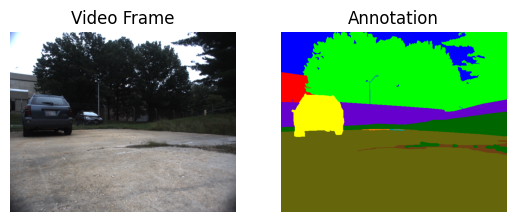

In [63]:
single_feature_plot()

Path: ..\..\data\RUGD\annotations\creek\creek_00011.png
Number of unique colors: 13


Class 'tree' takes up 30.78% of the total pixels on the image
Class 'sky' takes up 10.18% of the total pixels on the image
Class 'bush' takes up 16.25% of the total pixels on the image
Class 'container/generic-object' takes up 0.01% of the total pixels on the image
Class 'bridge' takes up 0.1% of the total pixels on the image
Class 'vehicle' takes up 0.81% of the total pixels on the image
Class 'grass' takes up 5.79% of the total pixels on the image
Class 'dirt' takes up 0.05% of the total pixels on the image
Class 'void' takes up 0.0% of the total pixels on the image
Class 'rock-bed' takes up 32.94% of the total pixels on the image
Class 'rock' takes up 0.26% of the total pixels on the image
Class 'water' takes up 0.3% of the total pixels on the image
Class 'sand' takes up 2.52% of the total pixels on the image
The percentages add up to (after rounding): 99.99%


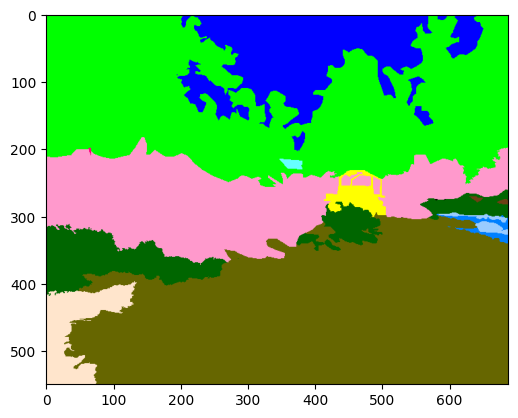

In [59]:
df = import_dataset()
single_image_pixel_dist(df, 2)

# Convert to grayscale (rgb -> id)

In [54]:
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, '../../src/utils')
import importlib
import convert_rgb2id
importlib.reload(convert_rgb2id)
from convert_rgb2id import rgb2id

rgb2id(df, rgb_to_id)

100%|██████████| 7436/7436 [02:04<00:00, 59.90it/s]


Number of unique colors on image: 13


<function matplotlib.pyplot.show(close=None, block=None)>

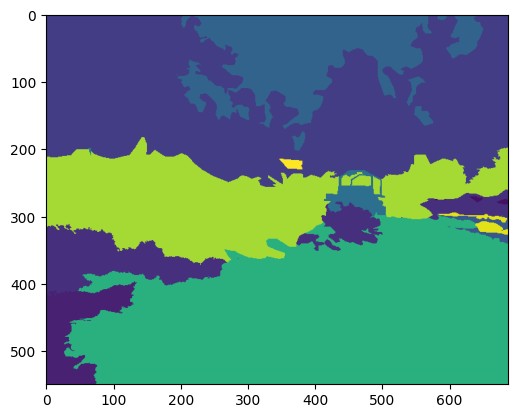

In [62]:
img = Image.open("../../data/processed/rugd/annotations_with_id/creek/creek_00011.png")
loaded = np.array(img)
print(f"Number of unique colors on image: {len(np.unique(loaded))}")
plt.imshow(img)
plt.show